In [ ]:
import pandas as pd
import torch
import torch.nn as nn 
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import tiktoken
from torch.utils.data import Dataset, DataLoader

In [2]:
df = pd.read_csv('../dataset/spam_ham_dataset.csv')
df.drop(['Unnamed: 0', 'label'], axis= 1, inplace=True)
num = df[df['label_num'] == 1].shape[0]
spam_subset = df[df['label_num'] == 1]

ham_subset = df[df['label_num'] == 0].sample(n=num, random_state=123)

balanced_df = pd.concat([ham_subset, spam_subset])
X_train, x_test, y_train, y_test = train_test_split(balanced_df.iloc[:, 0], balanced_df.iloc[: ,1], test_size=0.8)



In [ ]:
class CustomDataSet(Dataset):
    def __init__(self, features, targets, tokenizer, max_length=None, pad_token_id=50256):
        super().__init__()
        self.features = features
        self.targets = targets
        self.tokenizer = tokenizer
        
        self.tokenized_features = [self.tokenizer.encode(f) for f in self.features]
        if max_length is None:
            self.max_length = self._find_longest_sequence()
        else:
            self.max_length = max_length
            self.tokenized_features = [ f[: self.max_length] for f in self.tokenized_features]
        
        self.padded_encoded_features = [ f + [pad_token_id]* (self.max_length- len(f)) for f in self.tokenized_features]

    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, index):
        feature_at_index = self.padded_encoded_features[index]
        tokenized_feature_tensor = torch.tensor(feature_at_index, dtype=torch.long)
        target_tensor = torch.tensor(self.targets.iloc[index], dtype=torch.long)
        return tokenized_feature_tensor, target_tensor
    
    def _find_longest_sequence(self):
        print(len(self.tokenized_features))
        count_arr = [len(f) for f in self.tokenized_features]
        print(f'longest seq got : {max(count_arr)}')
        return max(count_arr)


def create_data_loader(features, targets, tokenizer, batch_size, shuffle,drop_last= True, max_length= None):
    dataset = CustomDataSet(features=features, targets=targets, tokenizer= tokenizer, max_length=max_length)
    data_loader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last)
    return data_loader

In [4]:
tokenizer = tiktoken.get_encoding('gpt2')


train_data_loader = create_data_loader(features=X_train, targets= y_train, batch_size=2, shuffle= True, drop_last=True, tokenizer= tokenizer, max_length= None) 
test_data_loader = create_data_loader(features=x_test, targets= y_test, batch_size=2, shuffle= True, drop_last=True, tokenizer= tokenizer, max_length=3447) 



599
longest seq got : 5970


In [5]:
dataset = CustomDataSet(features=X_train, targets= y_train, tokenizer= tokenizer)
dataset.__getitem__(1)


599
longest seq got : 5970


(tensor([19776,    25,   302,  ..., 50256, 50256, 50256]), tensor(0))

In [6]:
# JUST REPLACE HEAD LAYER with 2 OUTPUT NEURONS. KEEP ALL OTHER WEIGHTS FROZEN
# for param in model.parameters():
#     param.required_grad = False
 
# model.out_head = nn.Linear(768, 2)

# optionally as shown below we can also train last norm layer and last transformer block

# for param in model.[-1].parameters():
#     param.required_grad = True

# for param in model.final_norm.parameters():
#     param.required_grad = True
 


![alt text](image.png)

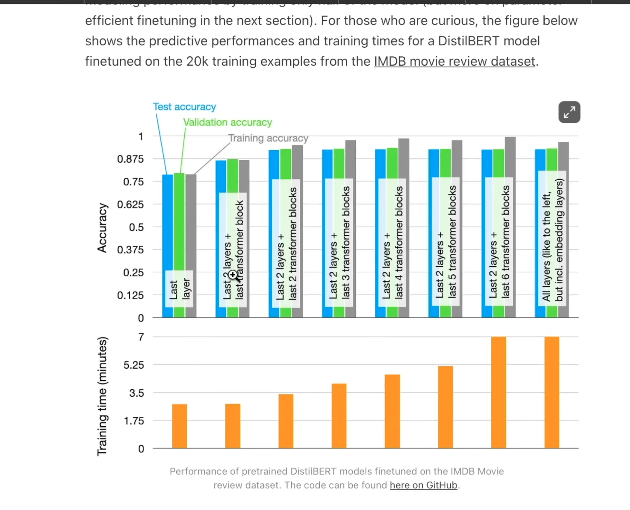

In [53]:
# Import pandas for reading the dataset
import pandas as pd

# Import PyTorch
import torch

# HuggingFace dataset object (efficient dataset wrapper)
from datasets import Dataset

# Import GPT2 tokenizer
from transformers import GPT2Tokenizer

# GPT2 model adapted for classification tasks
from transformers import GPT2ForSequenceClassification

# HuggingFace training utilities
from transformers import Trainer, TrainingArguments

# Train/validation split utility
from sklearn.model_selection import train_test_split

In [54]:
# -----------------------------
# 1. Load Dataset
# -----------------------------
df = pd.read_csv('../dataset/spam_ham_dataset.csv')
df.drop(['Unnamed: 0', 'label'], axis= 1, inplace=True)
num = df[df['label_num'] == 1].shape[0]
spam_subset = df[df['label_num'] == 1]

ham_subset = df[df['label_num'] == 0].sample(n=num, random_state=123)

balanced_df = pd.concat([ham_subset, spam_subset])
balanced_df.rename(columns={'label_num':'label'}, inplace=True)
balanced_df

train_df, val_df = train_test_split(balanced_df, test_size=0.2, random_state=42)

train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
df

,text,label_num
0,Subject: enron methanol ; meter # : 988291\r\n...,0
1,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,"Subject: photoshop , windows , office . cheap ...",1
4,Subject: re : indian springs\r\nthis deal is t...,0
...,...,...
5166,Subject: put the 10 on the ft\r\nthe transport...,0
5167,Subject: 3 / 4 / 2000 and following noms\r\nhp...,0
5168,Subject: calpine daily gas nomination\r\n>\r\n...,0
5169,Subject: industrial worksheets for august 2000...,0


In [55]:
# -------------------------------------------------
# 2. LOAD TOKENIZER
# -------------------------------------------------

# Load tokenizer for GPT2
# Tokenizer converts text -> tokens -> token IDs
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

# GPT2 does not have a padding token by default
# We assign EOS token as padding token
tokenizer.pad_token = tokenizer.eos_token
tokenizer.encode('HI')

[25374]

In [56]:
# -------------------------------------------------
# 3. TOKENIZATION FUNCTION
# -------------------------------------------------

# This function converts raw text into model inputs
def tokenize_function(example):

    return tokenizer(
        example["text"],      # email text
        truncation=True,      # cut sequences longer than max_length
        padding="max_length", # pad shorter sequences
        max_length=128        # maximum token length
    )


# Apply tokenization to datasets
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

# Convert dataset columns into PyTorch tensors
train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

val_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)
val_dataset

Map:   0%|          | 0/2398 [00:00<?, ? examples/s]

Map:   0%|          | 0/600 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', '__index_level_0__', 'input_ids', 'attention_mask'],
    num_rows: 600
})

In [57]:
# -------------------------------------------------
# 4. LOAD GPT MODEL
# -------------------------------------------------

# Load pretrained GPT2 model with a classification head
model = GPT2ForSequenceClassification.from_pretrained(
    "gpt2",       # pretrained GPT2 weights
    num_labels=2  # binary classification (spam or not spam)
)

# Assign padding token ID
model.config.pad_token_id = tokenizer.pad_token_id
device = torch.device('mps' if torch.backends.mps.is_available else 'cpu')
model.to(device)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2ForSequenceClassification LOAD REPORT from: gpt2
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


GPT2ForSequenceClassification(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (score): Linear(in_features=768, out_features=2, bias=False)
)

In [58]:
# -------------------------------------------------
# 5. FREEZE MOST MODEL PARAMETERS
# -------------------------------------------------

# Freeze all parameters first
for param in model.parameters():
    param.requires_grad = False
model

GPT2ForSequenceClassification(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (score): Linear(in_features=768, out_features=2, bias=False)
)

In [59]:
# -------------------------------------------------
# 6. UNFREEZE LAST TWO TRANSFORMER LAYERS
# -------------------------------------------------

# We unfreeze only the last norm layer
for param in model.transformer.ln_f.parameters():
    param.requires_grad = True

# GPT2 has 12 transformer layers
# They are stored in:
# model.transformer.h
# We unfreeze only the last Transformer layer
for layer in model.transformer.h[-1:]:

    for param in layer.parameters():

        param.requires_grad = True


In [60]:
# -------------------------------------------------
# 7. UNFREEZE CLASSIFICATION HEAD
# -------------------------------------------------

# Classification head converts final hidden state
# into spam/not-spam prediction
for param in model.score.parameters():

    param.requires_grad = True

In [49]:
# -------------------------------------------------
# 8. TRAINING ARGUMENTS
# -------------------------------------------------

# Define training configuration
training_args = TrainingArguments(

    output_dir="./results",      # directory where model checkpoints are saved

    learning_rate=2e-5,          # learning rate for optimizer

    per_device_train_batch_size=8,   # batch size during training

    per_device_eval_batch_size=8,    # batch size during evaluation

    num_train_epochs=3,          # number of training passes over dataset

    eval_strategy="epoch", # evaluate after every epoch

    save_strategy="epoch",       # save model after every epoch

    logging_dir="./logs",        # directory for training logs
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [62]:
for param in model.parameters():
    print(param.name, param.requires_grad)

None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False
None False

In [63]:
# -------------------------------------------------
# 9. TRAINER OBJECT
# -------------------------------------------------

# HuggingFace Trainer manages:
# training loop
# gradient updates
# evaluation
# checkpoint saving

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset,
)

In [64]:
# -------------------------------------------------
# 10. START TRAINING
# -------------------------------------------------

trainer.train()

/Users/netajisurve/Documents/GitHub-Projects/llm-from-scratch-learning/hub-projects/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,No log,nan
2,0.607348,nan
3,0.607348,nan


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/netajisurve/Documents/GitHub-Projects/llm-from-scratch-learning/hub-projects/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/netajisurve/Documents/GitHub-Projects/llm-from-scratch-learning/hub-projects/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=900, training_loss=0.3374157036675347, metrics={'train_runtime': 174.1994, 'train_samples_per_second': 41.297, 'train_steps_per_second': 5.166, 'total_flos': 469942205939712.0, 'train_loss': 0.3374157036675347, 'epoch': 3.0})

In [65]:
# -------------------------------------------------
# 11. SAVE TRAINED MODEL
# -------------------------------------------------

trainer.save_model("spam_classifier_gpt")

tokenizer.save_pretrained("spam_classifier_gpt")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('spam_classifier_gpt/tokenizer_config.json',
 'spam_classifier_gpt/tokenizer.json')

In [68]:
from transformers import GPT2Tokenizer, GPT2ForSequenceClassification
import torch

model = GPT2ForSequenceClassification.from_pretrained("spam_classifier_gpt")
tokenizer = GPT2Tokenizer.from_pretrained("spam_classifier_gpt")

text = "Congratulations! You won $1000"

inputs = tokenizer(text, return_tensors="pt")


outputs = model(**inputs)

prediction = torch.argmax(outputs.logits)

print("Spam" if prediction == 1 else "Not Spam")

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

Not Spam
